<a href="https://colab.research.google.com/github/jash1910/stock_price/blob/main/stock_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [55]:
df=pd.read_csv("/content/dirty_stock_data.csv")

In [56]:
df.head()

,date,ticker,open,high,low,close,volume,market_cap,pe_ratio,sector
0,2040-12-08,AAPL,108.59,111.13,104.60,107.18,1508533.0,1.816811e+14,20.06,Semiconductors
1,2020-07-21,TSLA,122.78,126.47,121.91,123.13,2128205.0,4.469660e+13,58.64,Technology
2,2027-07-30,TSLA,343.03,348.43,333.75,339.75,NaN,8.948448e+14,36.14,Consumer
3,2031-01-01,TSLA,747.68,768.12,741.79,750.66,6309411.0,7.521468e+14,15.89,Consumer
4,2037-05-02,AMZN,32.05,32.61,31.60,31.95,NaN,8.678870e+13,28.80,Semiconductors


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        102000 non-null  object 
 1   ticker      100023 non-null  object 
 2   open        96949 non-null   float64
 3   high        99003 non-null   float64
 4   low         98944 non-null   float64
 5   close       96950 non-null   object 
 6   volume      96913 non-null   float64
 7   market_cap  96905 non-null   float64
 8   pe_ratio    94959 non-null   float64
 9   sector      102000 non-null  object 
dtypes: float64(6), object(4)
memory usage: 7.8+ MB


In [58]:
df.describe()


,open,high,low,volume,market_cap,pe_ratio
count,96949.000000,99003.000000,98944.000000,9.691300e+04,9.690500e+04,94959.000000
mean,1135.465040,1145.163707,1110.309233,5.368026e+06,1.696893e+15,34.955065
std,1971.479844,1988.581421,1922.302822,6.919352e+06,3.539043e+15,14.434994
min,17.780000,9.630000,17.490000,-5.653023e+07,7.834033e+10,10.000000
25%,106.560000,107.260000,104.017500,1.664353e+06,1.219724e+14,22.470000
50%,258.770000,260.020000,252.560000,3.280514e+06,3.396775e+14,34.840000
75%,1148.370000,1157.885000,1122.815000,6.458134e+06,1.456908e+15,47.470000
max,33981.510000,19378.890000,18681.820000,1.654107e+08,5.591737e+16,60.000000


In [59]:
df.isnull().sum()

,0
date,0
ticker,1977
open,5051
high,2997
low,3056
close,5050
volume,5087
market_cap,5095
pe_ratio,7041
sector,0


In [60]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['close'] = pd.to_numeric(df['close'], errors='coerce')
df['volume'] = pd.to_numeric(df['volume'], errors='coerce')
df['pe_ratio'] = pd.to_numeric(df['pe_ratio'], errors='coerce')

In [61]:
df['ticker'] = df['ticker'].str.upper().str.strip()
df = df.dropna(subset=['ticker'])

In [62]:
df = df.drop_duplicates()

In [63]:
df = df[df['high'] >= df['low']]
df = df[df['open'] <= df['high']]
df = df[df['low'] <= df['close']]
df = df[df['volume'] >= 0]

In [64]:
df = df.sort_values(by=['ticker', 'date'])

cols_price = ['open', 'high', 'low', 'close']
cols_other = ['volume', 'market_cap', 'pe_ratio']

df[cols_price] = df.groupby('ticker')[cols_price].ffill()
df[cols_other] = df.groupby('ticker')[cols_other].ffill()

In [65]:
Q1 = df['close'].quantile(0.25)
Q3 = df['close'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['close'] >= Q1 - 1.5 * IQR) & (df['close'] <= Q3 + 1.5 * IQR)]

In [66]:
df = df.dropna()

In [67]:
df.to_csv("cleaned_stock_data.csv", index=False)
from google.colab import files
files.download("cleaned_stock_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
#EDA

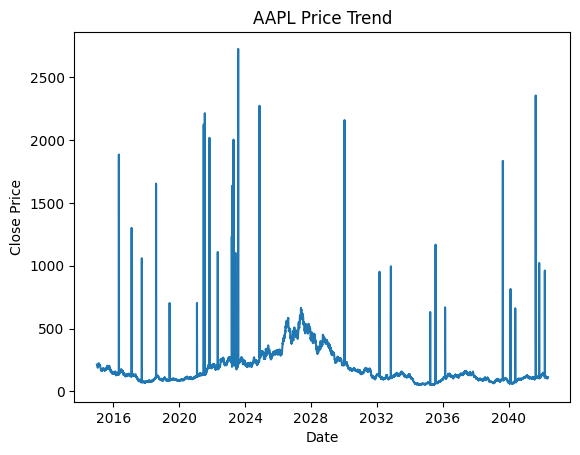

In [69]:
sample_ticker = df['ticker'].iloc[0]

subset = df[df['ticker'] == sample_ticker]

plt.figure()
plt.plot(subset['date'], subset['close'])
plt.title(f"{sample_ticker} Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

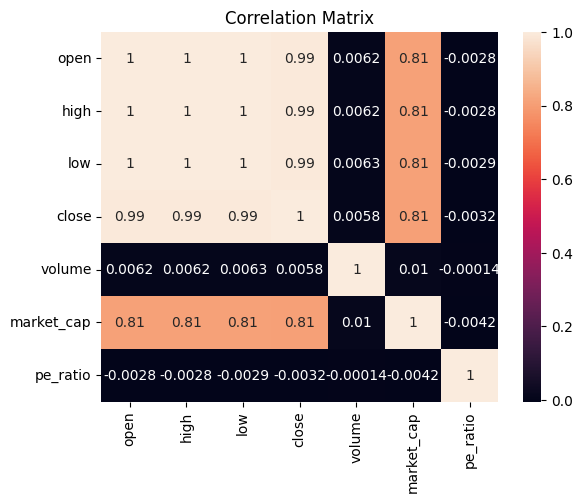

In [70]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

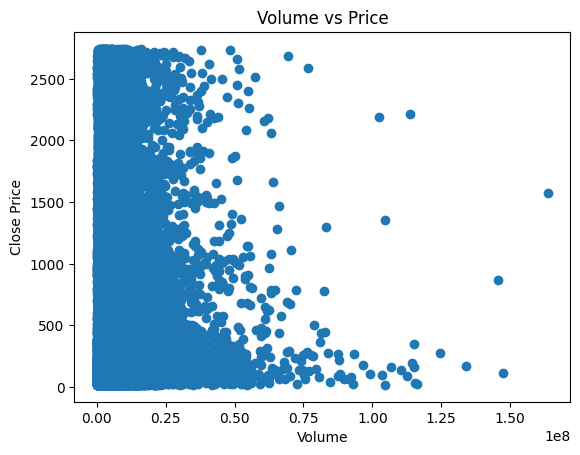

In [71]:
plt.figure()
plt.scatter(df['volume'], df['close'])
plt.xlabel("Volume")
plt.ylabel("Close Price")
plt.title("Volume vs Price")
plt.show()

In [72]:
#feature engineering

In [73]:
df['daily_return'] = df.groupby('ticker')['close'].pct_change()

df['ma7'] = df.groupby('ticker')['close'].rolling(7).mean().reset_index(0, drop=True)

df['volatility'] = df.groupby('ticker')['close'].rolling(7).std().reset_index(0, drop=True)

In [74]:
df = df.dropna()

In [75]:
#model training

In [76]:
features = ['open', 'high', 'low', 'volume', 'market_cap', 'pe_ratio', 'ma7', 'volatility']
target = 'close'

X = df[features]
y = df[target]

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [78]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_mse = mean_squared_error(y_test, rf_preds)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_preds)

print("\n===== Random Forest =====")
print("MAE  :", rf_mae)
print("MSE  :", rf_mse)
print("RMSE :", rf_rmse)
print("R2   :", rf_r2)


===== Random Forest =====
MAE  : 7.908215334824997
MSE  : 2313.5077350426614
RMSE : 48.09893694295812
R2   : 0.9947390902202479


In [79]:

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_mse = mean_squared_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, xgb_preds)

print("\n===== XGBoost =====")
print("MAE  :", xgb_mae)
print("MSE  :", xgb_mse)
print("RMSE :", xgb_rmse)
print("R2   :", xgb_r2)


===== XGBoost =====
MAE  : 10.600047815670996
MSE  : 2875.5560367756552
RMSE : 53.62421129280742
R2   : 0.9934609940364779


In [80]:
import joblib

joblib.dump(rf, "stock_model.pkl")

['stock_model.pkl']

In [81]:
features = ['open', 'high', 'low', 'volume', 'market_cap', 'pe_ratio', 'ma7', 'volatility']

joblib.dump(features, "features.pkl")

['features.pkl']